In [6]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Set seaborn style for better visuals
sns.set_theme(style="whitegrid")

--- Data Overview ---


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


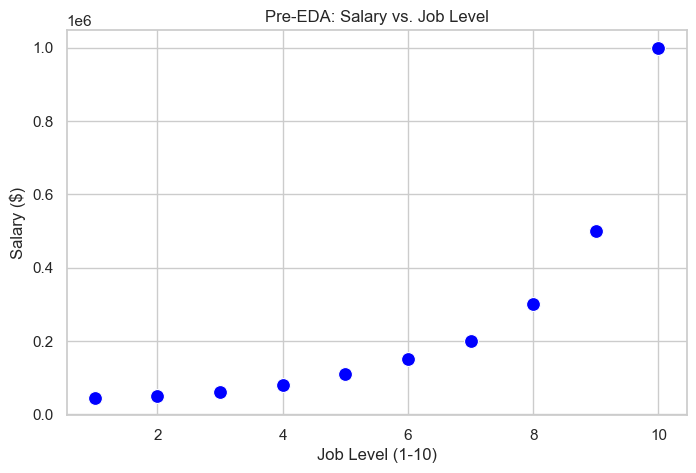

In [7]:
# Load the dataset (Make sure Position_Salaries.csv is in the same folder)
# Kaggle Link for reference: https://www.kaggle.com/datasets/karthickveerakumar/salary-data-simple-linear-regression
df = pd.read_csv('Position_Salaries.csv')

print("--- Data Overview ---")
display(df.head()) 

# Separate features and target
# We only use 'Level' as our feature, ignoring the categorical 'Position' name
X = df[['Level']].values 
y = df['Salary'].values

# Visualize the base relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Level', y='Salary', data=df, color='blue', s=100)
plt.title('Pre-EDA: Salary vs. Job Level')
plt.xlabel('Job Level (1-10)')
plt.ylabel('Salary ($)')
plt.show()

In [8]:
# Create the pipeline: 
# 1. Poly Features (degree 5 to give it plenty of options)
# 2. Standard Scaler (Mandatory for high degrees)
# 3. Lasso Regression (for automatic feature selection)

poly_lasso_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    # alpha controls the penalty. Higher alpha = more features dropped to zero
    ('lasso', Lasso(alpha=5000, max_iter=100000)) 
])

# Train the model
poly_lasso_pipeline.fit(X, y)
y_pred = poly_lasso_pipeline.predict(X)

print(f"Model R-squared Score: {r2_score(y, y_pred):.4f}")

Model R-squared Score: 0.9830


In [9]:
# Extract the steps from the pipeline to inspect them
poly_step = poly_lasso_pipeline.named_steps['poly']
lasso_step = poly_lasso_pipeline.named_steps['lasso']

# Get the names of the generated features (x0, x0^2, x0^3, etc.)
feature_names = poly_step.get_feature_names_out(['Level'])
coefficients = lasso_step.coef_

print("--- Feature Selection Results ---")
for name, coef in zip(feature_names, coefficients):
    status = "KEPT" if coef != 0 else "DROPPED (Zeroed out)"
    print(f"Feature {name:>9}: Weight = {coef:>12.2f}  [{status}]")

--- Feature Selection Results ---
Feature     Level: Weight =         0.00  [DROPPED (Zeroed out)]
Feature   Level^2: Weight =         0.00  [DROPPED (Zeroed out)]
Feature   Level^3: Weight =         0.00  [DROPPED (Zeroed out)]
Feature   Level^4: Weight =         0.00  [DROPPED (Zeroed out)]
Feature   Level^5: Weight =    276631.88  [KEPT]


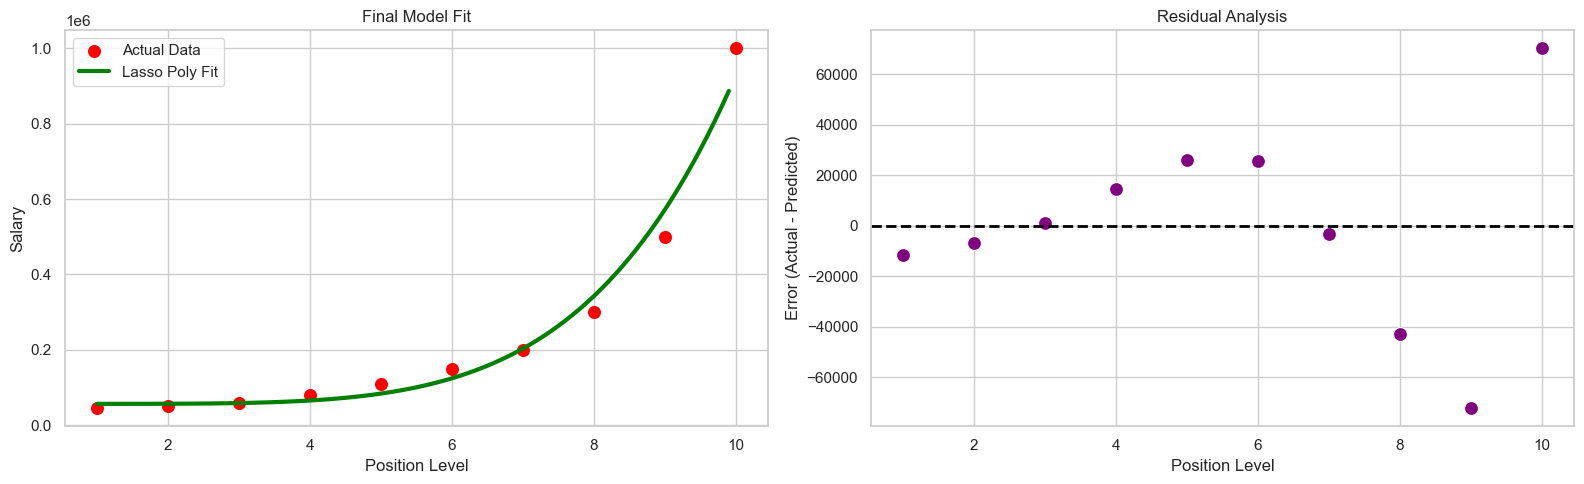

In [11]:
# Calculate residuals
residuals = y - y_pred

# Set up a 1x2 plot grid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: The Final Fit
# FIX: Used X.min() and X.max() instead of min(X) and max(X)
X_grid = np.arange(X.min(), X.max(), 0.1).reshape(-1, 1)
y_grid_pred = poly_lasso_pipeline.predict(X_grid)

ax1.scatter(X, y, color='red', label='Actual Data', s=70)
ax1.plot(X_grid, y_grid_pred, color='green', linewidth=3, label='Lasso Poly Fit')
ax1.set_title('Final Model Fit')
ax1.set_xlabel('Position Level')
ax1.set_ylabel('Salary')
ax1.legend()

# Plot 2: Residual Scatter Plot
sns.scatterplot(x=X.flatten(), y=residuals, ax=ax2, color='purple', s=100)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax2.set_title('Residual Analysis')
ax2.set_xlabel('Position Level')
ax2.set_ylabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()